# SSTI detection — model evaluation




In [1]:
"""
Reusable classical-ML modeling pipeline.
========================================

Design goal: point this at ANY tabular dataset with a label column and get
a fair, reproducible comparison of 7 classifiers. Works for binary problems and multiclass problems .

Pipeline shape (always the same order, because order is what protects
against data leakage):

    load_data  ->  split_data  ->  scale_features  ->  train  ->  evaluate

Why the order matters:
  - Split BEFORE scaling. The scaler is fitted on training data only, then
    reused to transform the test set. Fitting on the full dataset would leak
    test-set statistics (mean/std) into training — a classic reviewer catch.
  - Stratify the split so rare attack classes appear in both train and test
    at the same ratio as in the full dataset.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


# ======================================================================
# GLOBAL CONFIG 
# ======================================================================


RANDOM_STATE = 42     # one seed everywhere (split, CV, every model)
TEST_SIZE    = 0.2    # 80/20 train/test split

# Shared CV strategy for every tuned model.
# StratifiedKFold keeps class proportions identical in each fold — critical
# when some attack classes are rare. 3 folds instead of 5 because the
# datasets are large and 5 folds nearly doubles tuning time for little gain.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

## Data loading and preprocessing

In [2]:
# Load Data 
# FEATURES_FILE picks the feature version (added 2026-09-24).
#   'train_features.csv'    -> v1: the original 17 features
#   'train_features_v2.csv' -> v2: 18 features, see Dataset/scripts/ssti_feature_extraction_v2.py
# Same rows, same order, same base_id and label in both -- only feature columns differ.
# Nothing else needs changing: cell below takes every column except label and base_id.
FEATURES_FILE = 'train_features_v2.csv'
df = pd.read_csv(FEATURES_FILE)

# Drop Payload Column
df.drop(columns=['payload',], inplace=True)
df.head()



,base_id,payload_length,special_char_ratio,count_double_brace,count_dollar_brace,count_hash_brace,count_percent_brace,count_erb,delimiter_family_count,max_bracket_depth,has_dunder_chain,has_exec_tokens,has_java_reflection,has_flask_objects,has_arithmetic_operation,has_string_operation,count_method_calls,count_dots,label
0,<%=N*N%>,10,0.600000,0,0,0,0,2,1,0,0,0,0,0,1,0,0,0,1
1,<%=N*'S'%>,12,0.666667,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,1
2,"<%=""S""%>",12,0.583333,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,1
3,"<%=system(""S"")%>",19,0.473684,0,0,0,0,2,1,1,0,1,0,0,0,0,0,0,1
4,"<%=exec(""S"")%>",17,0.529412,0,0,0,0,2,1,1,0,1,0,0,0,0,0,0,1


In [4]:
#  SPLIT INTO INPUTS (X) AND ANSWER (y)
X = df.drop(columns=['label', 'base_id'])
Y = df.label

# Split Train and Test Data
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state = 15)

scaler = StandardScaler()
x_train["payload_length"] = scaler.fit_transform(x_train[["payload_length"]])
x_test["payload_length"]  = scaler.transform(x_test[["payload_length"]])
# print(x_train[["payload_length"]].head())




## Modeling and evaluation

In [5]:


# ======================================================================
# STEP 2 — TRAINING FUNCTIONS (one per model, training ONLY)
# ======================================================================
# Each function does exactly one thing: return a fitted model.
# No evaluation, no plotting — that separation is what makes the
# comparison fair (every model is judged by the same evaluate_model).

# --- Simple baselines: no tuning needed ------------------------------

def train_naive_bayes(X_train, y_train):
    # GaussianNB has essentially nothing worth tuning. It assumes feature
    # independence, which is false for both network traffic and payload
    # features, so expect it to be the weakest model — its job is to be
    # the floor the other models must beat.
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model


def train_logistic_regression(X_train, y_train):
    # class_weight="balanced" makes mistakes on rare classes cost more,
    # so the model can't win by always predicting the majority class.
    # max_iter raised so the optimizer converges on scaled features.
    model = LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


# --- Light tuning -----------------------------------------------------

def train_decision_tree(X_train, y_train):
    # The params dict is the experiment: these are the knobs being searched.
    params = {
        "max_depth": [None, 10, 20, 40],   # how deep the tree may grow
        "min_samples_leaf": [1, 5, 20],    # bigger leaves = less overfitting
        "criterion": ["gini", "entropy"],  # how splits are scored
    }
    search = RandomizedSearchCV(
        DecisionTreeClassifier(class_weight="balanced",
                               random_state=RANDOM_STATE),
        params,
        n_iter=8,
        scoring="f1_macro",   # macro-F1, not accuracy, so rare classes
                              # count equally — the honest metric for
                              # imbalanced security data
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# --- Slow models ------------------------------------------------------
# NOTE: on very large datasets (CICIDS2017 full), tune these on a
# stratified subsample first, then refit the best params on all data.
# On the SSTI dataset (~hundreds of rows) they run fine as-is.

def train_svm(X_train, y_train):
    params = {
        "C": [0.1, 1, 10],              # regularization strength
        "gamma": ["scale", 0.01, 0.1],  # reach of one sample's influence
    }
    search = RandomizedSearchCV(
        # probability=True is slower but required: without it SVM can't
        # output probabilities and ROC-AUC (our headline metric) fails.
        SVC(kernel="rbf", probability=True,
            class_weight="balanced", random_state=RANDOM_STATE),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


def train_knn(X_train, y_train):
    params = {
        "n_neighbors": [3, 5, 11, 21],       # how many neighbors vote
        "weights": ["uniform", "distance"],  # equal vote vs closer = louder
    }
    search = RandomizedSearchCV(
        KNeighborsClassifier(n_jobs=-1),
        params, n_iter=6, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# --- Models that genuinely benefit from tuning ------------------------

def train_random_forest(X_train, y_train):
    params = {
        "n_estimators": [200, 400, 600],   # number of trees
        "max_depth": [None, 20, 40],       # depth of each tree
        "min_samples_leaf": [1, 2, 5],     # overfitting control
        "max_features": ["sqrt", "log2"],  # features considered per split
    }
    search = RandomizedSearchCV(
        # "balanced_subsample" recomputes class weights per bootstrap
        # sample — the RF-appropriate version of "balanced".
        RandomForestClassifier(class_weight="balanced_subsample",
                               random_state=RANDOM_STATE, n_jobs=-1),
        params, n_iter=10, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


def train_xgboost(X_train, y_train):
    params = {
        "n_estimators": [300, 500, 800],    # boosting rounds
        "max_depth": [4, 6, 8],             # tree depth
        "learning_rate": [0.03, 0.1, 0.2],  # step size per round
        "subsample": [0.8, 1.0],            # row sampling per tree
        "colsample_bytree": [0.8, 1.0],     # feature sampling per tree
    }

    # Pick the eval metric from the data itself, so the same function is correct for the binary SSTI problem ("logloss") and the multiclass
    # CICIDS2017 problem ("mlogloss") with no manual switching. Note: since we don't pass an eval_set, this metric doesn't drive
    # training — hyperparameters are chosen by scoring="f1_macro" below. It's set explicitly anyway so the configuration is self-documenting and defensible in the paper.
    n_classes = len(np.unique(y_train))
    metric = "logloss" if n_classes == 2 else "mlogloss"

    search = RandomizedSearchCV(
        # tree_method="hist" = fast histogram algorithm, matters at
        # CICIDS2017 scale.
        XGBClassifier(tree_method="hist", eval_metric=metric,
                      n_jobs=-1, random_state=RANDOM_STATE),
        params, n_iter=12, scoring="f1_macro", cv=cv,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print("  best params:", search.best_params_)
    return search.best_estimator_


# ======================================================================
# STEP 3 — EVALUATION (one function, every model, same rules)
# ======================================================================

def evaluate_model(name, model, X_test, y_test, class_names=None):
    """
    Evaluate one fitted model and return its metrics as a dict.

    Handles binary AND multiclass automatically:
      - Binary (SSTI): roc_auc_score wants ONLY the positive-class
        probability, i.e. y_prob[:, 1].
      - Multiclass (CICIDS2017): it wants the full probability matrix
        plus multi_class='ovr'.
    Getting this wrong is a silent bug — sklearn raises an error in one
    direction but in the other it can compute a misleading number.

    Returns the metrics (instead of only printing) so a comparison table
    can be built across models — that table becomes the results section
    of the paper.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    n_classes = len(np.unique(y_test))
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_test, y_prob,
                            multi_class="ovr", average="macro")
    print(f"ROC-AUC: {auc:.4f}")

    # Confusion matrix heatmap — labeled with real class names when known.
    ticks = class_names if class_names is not None else "auto"
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=ticks, yticklabels=ticks)
    plt.title(f"Confusion matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {
        "model": name,
        "roc_auc": auc,
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
    }



  



  best params: {'min_samples_leaf': 5, 'max_depth': None, 'criterion': 'entropy'}
  best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
  best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
  best params: {'weights': 'distance', 'n_neighbors': 3}
  best params: {'gamma': 0.1, 'C': 10}

  Naive Bayes
              precision    recall  f1-score   support

           0       0.69      0.99      0.82       389
           1       0.98      0.57      0.72       393

    accuracy                           0.78       782
   macro avg       0.84      0.78      0.77       782
weighted avg       0.84      0.78      0.77       782

ROC-AUC: 0.9353


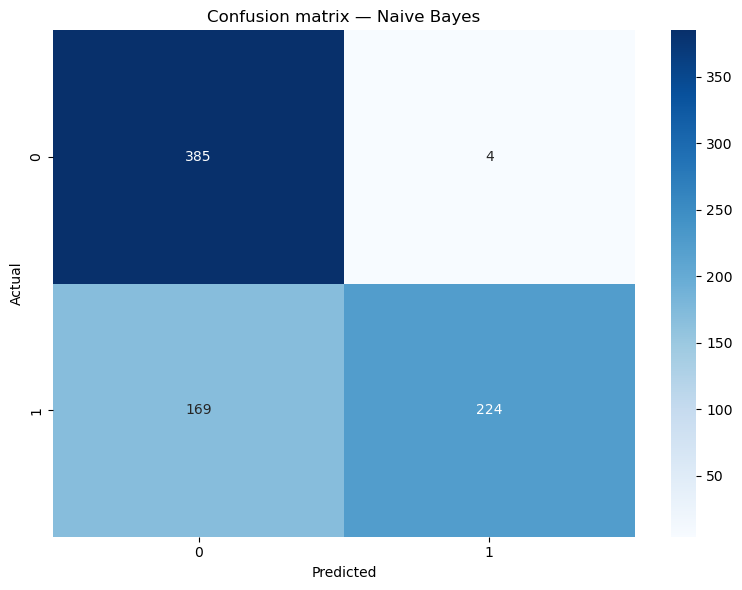


  Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       389
           1       0.91      0.84      0.87       393

    accuracy                           0.88       782
   macro avg       0.88      0.88      0.88       782
weighted avg       0.88      0.88      0.88       782

ROC-AUC: 0.9578


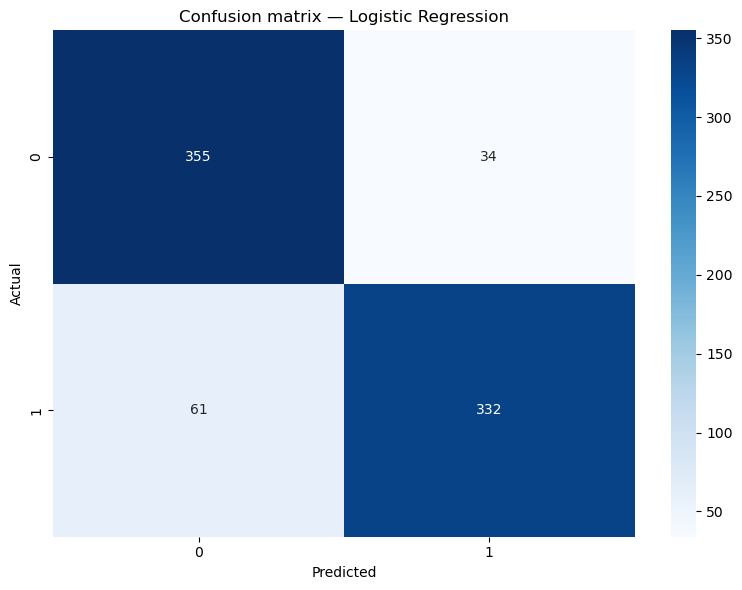


  Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       389
           1       0.89      0.90      0.89       393

    accuracy                           0.89       782
   macro avg       0.89      0.89      0.89       782
weighted avg       0.89      0.89      0.89       782

ROC-AUC: 0.9423


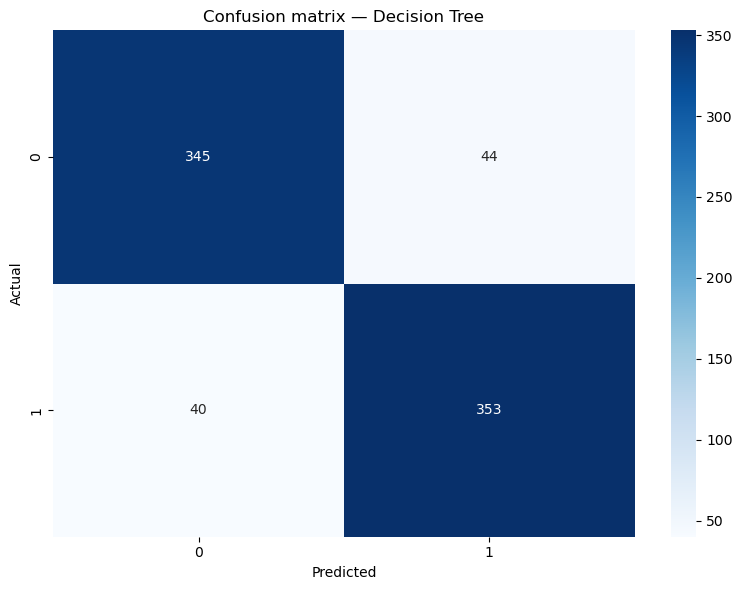


  Random Forest
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       389
           1       0.91      0.92      0.91       393

    accuracy                           0.91       782
   macro avg       0.91      0.91      0.91       782
weighted avg       0.91      0.91      0.91       782

ROC-AUC: 0.9766


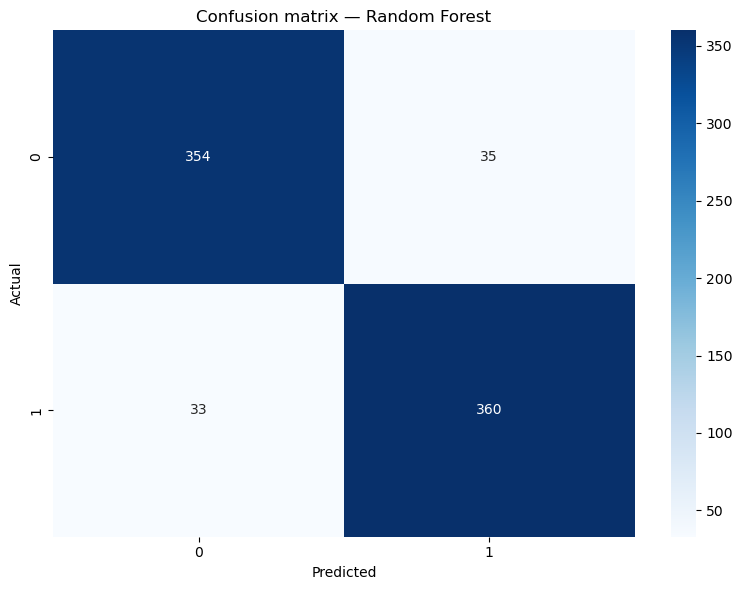


  XGBoost
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       389
           1       0.92      0.92      0.92       393

    accuracy                           0.92       782
   macro avg       0.92      0.92      0.92       782
weighted avg       0.92      0.92      0.92       782

ROC-AUC: 0.9786


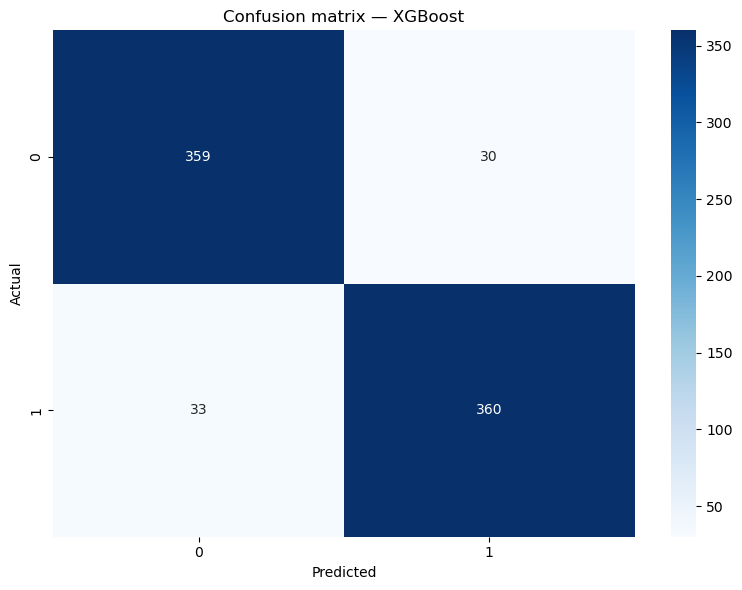


  KNN
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       389
           1       0.93      0.89      0.91       393

    accuracy                           0.91       782
   macro avg       0.91      0.91      0.91       782
weighted avg       0.91      0.91      0.91       782

ROC-AUC: 0.9443


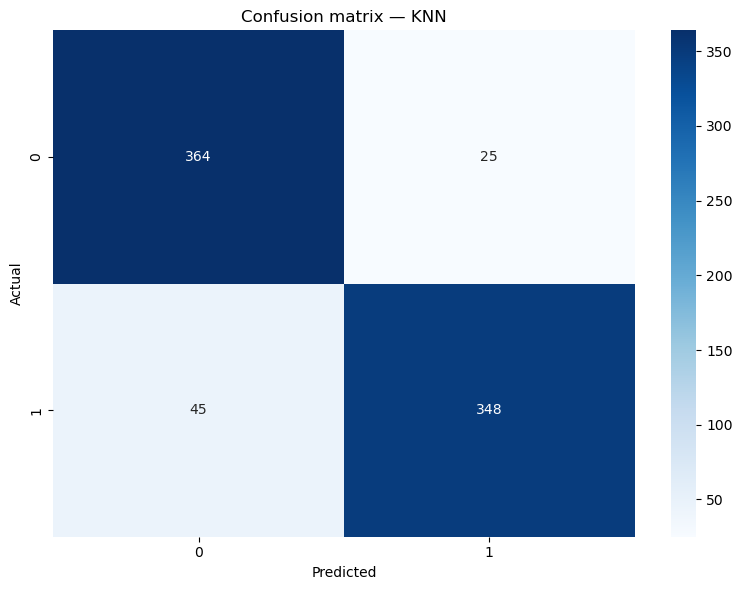


  SVM
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       389
           1       0.93      0.90      0.91       393

    accuracy                           0.92       782
   macro avg       0.92      0.92      0.92       782
weighted avg       0.92      0.92      0.92       782

ROC-AUC: 0.9733


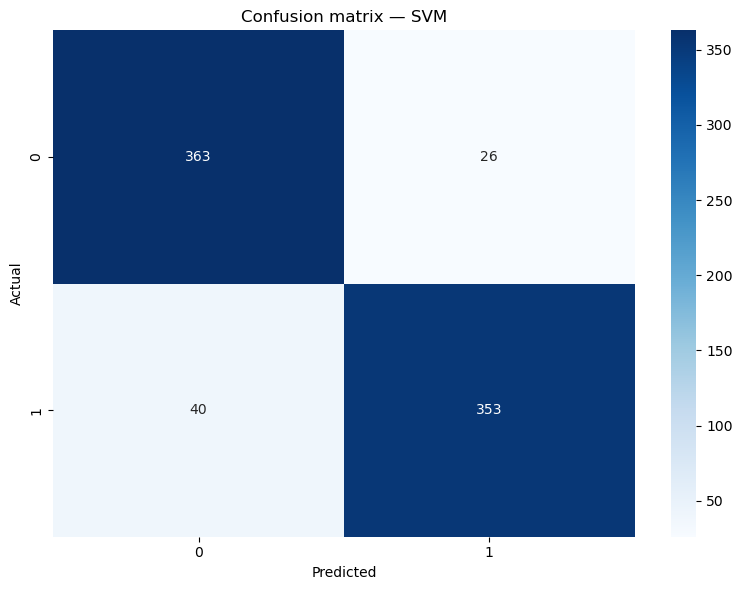

In [ ]:
class_names = ['BENIGN', 'SSTI_Vulnerable']

# Train each model. Each function returns a fitted, ready-to-use model.
models = {
    "Naive Bayes":         train_naive_bayes(x_train, y_train),
    "Logistic Regression": train_logistic_regression(x_train, y_train),
    "KNN":                 train_knn(x_train, y_train),
    "SVM":                 train_svm(x_train, y_train),
    "Decision Tree":       train_decision_tree(x_train, y_train),
    "Random Forest":       train_random_forest(x_train, y_train),
    "XGBoost":             train_xgboost(x_train, y_train),
}

# Evaluate each trained model with the same function, so the comparison is fair.
for name, mdl in models.items():
    evaluate_model(name, mdl, x_test, y_test) 

## NEW — added 24 September 2026: threshold selection

Runs right after the models cell above. Picks the probability cutoff from **training data only**
(grouped by `base_id`, 5 folds, targeting a 5% false-alarm rate on benign rows), then reports
precision, recall, F1 and false alarms at 0.5 and at the chosen cutoff, on your internal test
split and on the external test file. Nothing above this cell was changed; it only calls
`train_xgboost`, `train_random_forest` and the models already trained.

In [ ]:
# ======================================================================
# NEW (2026-09-24) — THRESHOLD SELECTION.  Not part of the original pipeline.
# ======================================================================
# Uses only what cells above already created: df, x_train, y_train, x_test,
# y_test, scaler, models, FEATURES_FILE, train_xgboost, train_random_forest.
# None of those functions are modified -- this cell only calls them.
#
# WHY: every model outputs a probability, and predict() cuts it at 0.5.
# 0.5 is arbitrary. Here the cutoff is chosen from TRAINING data only, then
# applied once to the test sets. Choosing it on a test set would make the
# test result a cherry-pick instead of a measurement.
#
# WHY A FALSE-ALARM TARGET AND NOT "BEST F1": the best-F1 cutoff depends on
# what share of rows are attacks. Training is ~49% attacks, the external set
# ~9%, so a best-F1 cutoff from training is wrong for external. A false-alarm
# rate is measured on benign rows alone, so it carries over.
#
# Runtime: a few minutes (each model's hyperparameter search runs 5 times).

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

TARGET_FPR = 0.05   # flag at most 5% of benign TRAINING rows


def select_threshold(train_fn, X, y, groups, target_fpr=TARGET_FPR, n_folds=5):
    """Pick a probability cutoff using training data only.

    1. Split the training data into folds, grouped by base_id so variants of
       one payload never sit on both sides.
    2. For each fold, train a fresh model on the other folds (with your own
       train_fn) and score the held-out fold. Every training row ends up with
       a probability from a model that never saw it.
    3. Return the cutoff that flags `target_fpr` of the benign rows.
    """
    oof = np.zeros(len(y))
    folds = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    for fit_idx, held_idx in folds.split(X, y, groups):
        fold_model = train_fn(X.iloc[fit_idx], y.iloc[fit_idx])
        oof[held_idx] = fold_model.predict_proba(X.iloc[held_idx])[:, 1]
    benign_scores = oof[y.to_numpy() == 0]
    return float(np.quantile(benign_scores, 1 - target_fpr))


def metrics_at(model, X, y, threshold):
    """Precision, recall, F1 and false-alarm rate at a given cutoff."""
    y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "false_alarm_rate": fp / (fp + tn),
        "false_alarms": int(fp),
        "missed_attacks": int(fn),
    }


# base_id for each training row. df still holds it; x_train kept df's row index.
train_groups = df.loc[x_train.index, "base_id"]

# External test file matching the feature version chosen in cell 3
# ('train_features_v2.csv' -> 'test_features_v2.csv'). Same column order as
# x_train, and payload_length scaled with the scaler fitted in cell 4.
external_file = FEATURES_FILE.replace("train_", "test_")
external = pd.read_csv(external_file)
x_external = external[x_train.columns].copy()
x_external["payload_length"] = scaler.transform(x_external[["payload_length"]])
y_external = external["label"]
print(f"external file: {external_file}  ({len(external)} rows, {int(y_external.sum())} attacks)")

# Tree models only: they ignore feature scaling, so the cell-4 scaler (fitted
# on all of x_train) cannot leak into the folds above.
threshold_rows = []
for name, train_fn in [("XGBoost", train_xgboost), ("Random Forest", train_random_forest)]:
    print(f"\nselecting threshold for {name} ...")
    chosen = select_threshold(train_fn, x_train, y_train, train_groups)
    print(f"  chosen threshold: {chosen:.3f}")
    fitted = models[name]   # trained in the cell above, on all of x_train
    for set_name, X, y in [("internal (x_test)", x_test, y_test),
                           ("external", x_external, y_external)]:
        for label, t in [("default 0.50", 0.5), ("chosen", chosen)]:
            threshold_rows.append({"model": name, "set": set_name, "cutoff": label,
                                   "threshold": round(t, 3), **metrics_at(fitted, X, y, t)})

threshold_table = pd.DataFrame(threshold_rows).round(3)
threshold_table


In [ ]:
from pathlib import Path
from types import FunctionType
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
from IPython.display import display
from datetime import datetime, timezone
import hashlib, json, platform, time, warnings
import sklearn, xgboost

group_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'Dataset/train/combined/train_features.csv').exists())
group_train_path = group_root/'Dataset/train/combined/train_features.csv'
group_external_path = group_root/'Dataset/test_set/features/test_features.csv'
group_data = pd.read_csv(group_train_path, keep_default_na=False)
group_external = pd.read_csv(group_external_path, keep_default_na=False)
group_features = [c for c in group_data if c not in ('payload','base_id','label')]
assert len(group_features) == 17
assert group_features == [c for c in group_external if c not in ('payload','base_id','label')]
group_X, group_y = group_data[group_features], group_data.label.astype(int)
group_ids = group_data.base_id.astype(str)
group_external_X, group_external_y = group_external[group_features], group_external.label.astype(int)
assert np.isfinite(group_X.to_numpy()).all() and np.isfinite(group_external_X.to_numpy()).all()
assert set(group_y) == set(group_external_y) == {0,1}
assert group_ids.str.len().gt(0).all()
assert (Path('train_features.csv').read_bytes() == group_train_path.read_bytes())
group_binary = ['has_dunder_chain','has_exec_tokens','has_java_reflection','has_flask_objects','has_arithmetic_operation','has_string_operation']
group_seed = 42
group_outer_candidates = list(StratifiedGroupKFold(5, shuffle=True, random_state=group_seed).split(group_X,group_y,group_ids))
group_outer_choice = min(range(5), key=lambda i: (abs(len(group_outer_candidates[i][1])/len(group_data)-0.2)/0.2 + abs(group_y.iloc[group_outer_candidates[i][1]].mean()-group_y.mean()), i))
group_fit_rows, group_holdout_rows = group_outer_candidates[group_outer_choice]
group_inner = list(StratifiedGroupKFold(3,shuffle=True,random_state=group_seed).split(group_X.iloc[group_fit_rows],group_y.iloc[group_fit_rows],group_ids.iloc[group_fit_rows]))
group_split_table = []
for name,a,b in [('Outer holdout',group_fit_rows,group_holdout_rows)] + [(f'Inner fold {i+1}',group_fit_rows[a],group_fit_rows[b]) for i,(a,b) in enumerate(group_inner)]:
    shared = len(set(group_ids.iloc[a]) & set(group_ids.iloc[b]))
    assert shared == 0
    assert set(group_y.iloc[a]) == set(group_y.iloc[b]) == {0,1}
    group_split_table.append({'split':name,'training_rows':len(a),'validation_rows':len(b),'training_positive_rate':group_y.iloc[a].mean(),'validation_positive_rate':group_y.iloc[b].mean(),'shared_groups':shared})
display(pd.DataFrame(group_split_table).round(4))
group_trainers = {'Naive Bayes':train_naive_bayes,'Logistic Regression':train_logistic_regression,'Decision Tree':train_decision_tree,'Random Forest':train_random_forest,'XGBoost':train_xgboost,'KNN':train_knn,'SVM':train_svm}
group_search_class = RandomizedSearchCV
group_models, group_candidates, group_results, group_warnings = {}, [], [], []
group_manifest = {'started_utc':datetime.now(timezone.utc).isoformat(),'seed':group_seed,'train_sha256':hashlib.sha256(group_train_path.read_bytes()).hexdigest(),'external_sha256':hashlib.sha256(group_external_path.read_bytes()).hexdigest(),'outer_fold':group_outer_choice,'outer_choice_rule':'minimum relative size error plus absolute positive-rate error; no model scores','preprocessing_candidates':['length_only','numeric'],'selection_score':'inner grouped CV macro-F1','original_functions_modified':False,'versions':{'python':platform.python_version(),'sklearn':sklearn.__version__,'xgboost':xgboost.__version__},'fit_rows':group_fit_rows.tolist(),'holdout_rows':group_holdout_rows.tolist(),'inner_validation_positions':[b.tolist() for a,b in group_inner]}

def group_metrics(reading, name, model, features, labels):
    pred = model.predict(features)
    tn,fp,fn,tp = confusion_matrix(labels,pred,labels=[0,1]).ravel()
    return {'reading':reading,'model':name,'n':len(labels),'accuracy':accuracy_score(labels,pred),'macro_f1':f1_score(labels,pred,average='macro'),'ssti_recall':recall_score(labels,pred,zero_division=0),'ssti_precision':precision_score(labels,pred,zero_division=0),'roc_auc':roc_auc_score(labels,model.predict_proba(features)[:,1]),'false_positive_rate':fp/(fp+tn),'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}

baseline_reading = pd.DataFrame([group_metrics('Basic holdout',name,model,x_test,y_test) for name,model in models.items()])
display(baseline_reading.round(4))

In [ ]:
def group_preprocessor(mode):
    columns = ['payload_length'] if mode == 'length_only' else [c for c in group_features if c not in group_binary]
    return ColumnTransformer([('scale',StandardScaler(),columns)],remainder='passthrough')

def group_train_candidate(name, mode):
    original_trainer = group_trainers[name]
    namespace = dict(original_trainer.__globals__)
    searches = []

    def make_search(estimator, param_distributions, **kwargs):
        pipe = Pipeline([('preprocess',group_preprocessor(mode)),('model',estimator)])
        parameters = {f'model__{k}':v for k,v in param_distributions.items()}
        kwargs['cv'] = group_inner
        search = group_search_class(pipe,parameters,**kwargs)
        searches.append(search)
        return search

    namespace['RandomizedSearchCV'] = make_search
    if name in ('Naive Bayes','Logistic Regression'):
        constructor_name = 'GaussianNB' if name == 'Naive Bayes' else 'LogisticRegression'
        constructor = namespace[constructor_name]
        namespace[constructor_name] = lambda *args, **kwargs: Pipeline([('preprocess',group_preprocessor(mode)),('model',constructor(*args,**kwargs))])
    trainer = FunctionType(original_trainer.__code__,namespace,original_trainer.__name__,original_trainer.__defaults__,original_trainer.__closure__)
    np.random.seed(group_seed)
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as observed:
        warnings.simplefilter('always')
        model = trainer(group_X.iloc[group_fit_rows],group_y.iloc[group_fit_rows])
        if searches:
            score = float(searches[0].best_score_)
            params = searches[0].best_params_
        else:
            scores = cross_val_score(clone(model),group_X.iloc[group_fit_rows],group_y.iloc[group_fit_rows],cv=group_inner,scoring='f1_macro',n_jobs=4,error_score='raise')
            score, params = float(scores.mean()), model.named_steps['model'].get_params()
    messages = sorted({f'{w.category.__name__}: {w.message}' for w in observed})
    group_warnings.append({'model':name,'preprocessing':mode,'warnings':messages})
    for message in messages:
        print(message)
    group_candidates.append({'model':name,'preprocessing':mode,'inner_cv_macro_f1':score,'training_seconds':time.perf_counter()-start,'parameters':params})
    return model,score

def group_run(name):
    fitted = {mode:group_train_candidate(name,mode) for mode in ('length_only','numeric')}
    selected = max(fitted,key=lambda mode:fitted[mode][1])
    model = fitted[selected][0]
    group_models[name] = model
    display(pd.DataFrame([r for r in group_candidates if r['model']==name])[['model','preprocessing','inner_cv_macro_f1','training_seconds']].round(4))
    print('Selected:',selected)
    for population,features,labels in [('Grouped holdout',group_X.iloc[group_holdout_rows],group_y.iloc[group_holdout_rows]),('Grouped external',group_external_X,group_external_y)]:
        evaluate_model(f'{name} | {population}',model,features,labels,['BENIGN','SSTI'])
        row = group_metrics(population,name,model,features,labels)
        row['preprocessing'] = selected
        group_results[:] = [r for r in group_results if (r['model'],r['reading']) != (name,population)]
        group_results.append(row)
    display(pd.DataFrame([r for r in group_results if r['model']==name]).round(4))

In [ ]:
group_run('Naive Bayes')

In [ ]:
group_run('Logistic Regression')

In [ ]:
group_run('Decision Tree')

In [ ]:
group_run('Random Forest')

In [ ]:
group_run('XGBoost')

In [ ]:
group_run('KNN')

In [ ]:
group_run('SVM')

In [ ]:
group_reading = pd.DataFrame(group_results)
assert len(group_reading)==14 and not group_reading.duplicated(['model','reading']).any()
assert (group_reading[['tn','fp','fn','tp']].sum(axis=1)==group_reading.n).all()
display(pd.concat([baseline_reading,group_reading[group_reading.reading.eq('Grouped holdout')]]).pivot(index='model',columns='reading',values=['accuracy','macro_f1','ssti_recall','roc_auc']).round(4))
display(group_reading[group_reading.reading.eq('Grouped external')].round(4))
display(pd.DataFrame(group_candidates)[['model','preprocessing','inner_cv_macro_f1','training_seconds']].round(4))
group_manifest['completed_utc']=datetime.now(timezone.utc).isoformat()
group_manifest['candidates']=group_candidates
group_manifest['warnings']=group_warnings
for p,key in [(group_train_path,'train_sha256'),(group_external_path,'external_sha256')]:
    assert hashlib.sha256(p.read_bytes()).hexdigest()==group_manifest[key]
from IPython.display import JSON
display(JSON(group_manifest,expanded=False))

In [ ]:
MODEL_TRAINERS = group_trainers.copy()

def run_pipeline(preprocess_fn, csv_path, models_to_run=None):
    """
    The full experiment: preprocess -> train all -> evaluate all.

    preprocess_fn: the dataset-specific preprocessing function to use
    (e.g. preprocess_ssti today, preprocess_cicids later). Each dataset
    gets its own function with its own quirks; the pipeline just calls
    whichever one it's handed. It must return, in this order:
        x_train, x_test, y_train, y_test, class_names, scaler

    models_to_run: optional list of names from MODEL_TRAINERS, so you can
    do a quick run with just ["Naive Bayes", "Decision Tree"] while
    iterating on features, then run everything for the final results.

    Returns (models, results_df, scaler) so you can inspect any fitted
    model afterwards (e.g. feature importances, SHAP) and reuse the
    scaler on new data.
    """
    # --- data ---
    # All dataset-specific logic lives inside preprocess_fn; the pipeline
    # only depends on the agreed return order.
    (x_train, x_test, y_train, y_test,
     class_names, scaler) = preprocess_fn(csv_path)

    # --- train ---
    if models_to_run is None:
        models_to_run = list(MODEL_TRAINERS.keys())

    models = {}
    for name in models_to_run:
        print(f"\nTraining {name} ...")
        models[name] = MODEL_TRAINERS[name](x_train, y_train)

    # --- evaluate ---
    results = []
    for name, mdl in models.items():
        results.append(
            evaluate_model(name, mdl, x_test, y_test, class_names)
        )

    # Final comparison table, best model first — this is the headline
    # table for the paper's results section.
    results_df = (pd.DataFrame(results)
                    .sort_values("f1_macro", ascending=False)
                    .reset_index(drop=True))
    print("\n" + "="*50)
    print("  FINAL COMPARISON")
    print("="*50)
    print(results_df.to_string(index=False))

    return models, results_df, scaler